In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_2016 = pd.read_csv('/content/2016 Dataset.csv')
df_2021 = pd.read_csv('/content/2021 Dataset.csv')
df_2024 = pd.read_csv('/content/Provincial.csv')

**Data Understanding**

In [ ]:
df_2016.shape

(40706, 11)

In [ ]:
df_2021.shape

(76740, 11)

In [ ]:
df_2024.shape

(734251, 10)

In [ ]:
df_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40706 entries, 0 to 40705
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           40706 non-null  object
 1   Municipality       40706 non-null  object
 2   Ward               40706 non-null  object
 3   VotingDistrict     40706 non-null  int64 
 4   VotingStationName  40706 non-null  object
 5   RegisteredVoters   40706 non-null  int64 
 6   BallotType         40706 non-null  object
 7   SpoiltVotes        40706 non-null  int64 
 8   PartyName          40706 non-null  object
 9   TotalValidVotes    40706 non-null  int64 
 10  DateGenerated      40706 non-null  object
dtypes: int64(4), object(7)
memory usage: 3.4+ MB


In [ ]:
df_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76740 entries, 0 to 76739
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           76740 non-null  object
 1   Municipality       76740 non-null  object
 2   Ward               76740 non-null  object
 3   VotingDistrict     76740 non-null  int64 
 4   VotingStationName  76740 non-null  object
 5   RegisteredVoters   76740 non-null  int64 
 6   BallotType         76740 non-null  object
 7   SpoiltVotes        76740 non-null  int64 
 8   PartyName          76740 non-null  object
 9   TotalValidVotes    76740 non-null  int64 
 10  DateGenerated      76740 non-null  object
dtypes: int64(4), object(7)
memory usage: 6.4+ MB


In [ ]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734251 entries, 0 to 734250
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Province               734251 non-null  object
 1   Municipality           734251 non-null  object
 2   VD_Number              734251 non-null  int64 
 3   VS_Name                734251 non-null  object
 4   Registered_Population  734251 non-null  int64 
 5   Spoilt_Votes           734251 non-null  int64 
 6   Total_Valid_Votes      734251 non-null  int64 
 7   sPartyName             734251 non-null  object
 8   Party_Votes            734251 non-null  int64 
 9   Generated_Datetime     734251 non-null  object
dtypes: int64(5), object(5)
memory usage: 56.0+ MB


In [ ]:
df_2016.describe()

,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,4.070600e+04,40706.000000,40706.000000,40706.000000
mean,4.342055e+07,2218.242618,29.917383,54.675109
std,1.042235e+05,1216.222531,51.968268,231.244162
min,4.335002e+07,101.000000,0.000000,0.000000
25%,4.336173e+07,1376.000000,6.000000,0.000000
50%,4.337163e+07,2098.000000,17.000000,1.000000
75%,4.340054e+07,2827.000000,36.000000,6.000000
max,4.407007e+07,8099.000000,993.000000,4175.000000


In [ ]:
df_2021.describe()

,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,7.674000e+04,76740.000000,76740.000000,76740.000000
mean,4.342097e+07,2183.586591,18.878512,20.207858
std,1.024769e+05,1190.978470,20.908777,103.494452
min,4.335002e+07,107.000000,0.000000,0.000000
25%,4.336174e+07,1358.000000,6.000000,0.000000
50%,4.337169e+07,2056.000000,13.000000,0.000000
75%,4.340058e+07,2823.000000,25.000000,2.000000
max,4.407007e+07,7910.000000,221.000000,3163.000000


In [ ]:
df_2024.describe()

,VD_Number,Registered_Population,Spoilt_Votes,Total_Valid_Votes,Party_Votes
count,7.342510e+05,734251.000000,734251.000000,734251.000000,734251.000000
mean,4.755977e+07,1261.971004,7.187061,727.109228,21.613556
std,2.705279e+07,1097.439185,11.546685,682.146704,111.748350
min,1.002001e+07,4.000000,0.000000,0.000000,0.000000
25%,3.284096e+07,469.000000,2.000000,252.000000,0.000000
50%,4.350521e+07,919.000000,4.000000,505.000000,0.000000
75%,7.620060e+07,1753.000000,9.000000,1001.000000,2.000000
max,9.843030e+07,8714.000000,352.000000,6297.000000,4995.000000


In [ ]:
# Define core party focus list (Major parties in eThekwini)
KEY_PARTIES = ['MK_Party', 'ANC', 'DA', 'EFF', 'IFP', 'ActionSA']

# Party standardization map across all datasets
PARTY_MAP = {
    'UMKHONTO WESIZWE': 'MK_Party',
    'MK PARTY': 'MK_Party',
    'MKP': 'MK_Party',
    'AFRICAN NATIONAL CONGRESS': 'ANC',
    'DEMOCRATIC ALLIANCE': 'DA',
    'ECONOMIC FREEDOM FIGHTERS': 'EFF',
    'INKATHA FREEDOM PARTY': 'IFP',
    'ACTIONSA': 'ActionSA'
}

def preprocess_and_clean(df, year):
    """
    Standardizes schema, harmonizes party names, groups minor parties into 'Others',
    and computes percentage vote share per ward.
    """
    data = df.copy()

    # 1. Standardize column headers
    data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

    # 2. Rename variable fields if necessary (handles common IEC header formats)
    column_renames = {
        'ward_no': 'ward_id',
        'wardno': 'ward_id',
        'party_name': 'party',
        'valid_votes': 'votes',
        'total_valid_votes': 'total_votes'
    }
    data = data.rename(columns=column_renames)

    # 3. Standardize Ward IDs (Format: 'Ward_001', 'Ward_002', ...)
    data['ward_id'] = data['ward_id'].astype(str).str.extract(r'(\d+)')[0]
    data['ward_id'] = 'Ward_' + data['ward_id'].str.zfill(3)

    # 4. Standardize Party Names
    data['party'] = data['party'].astype(str).str.strip().str.upper()
    data['party'] = data['party'].map(lambda p: PARTY_MAP.get(p, 'Others'))

    # 5. Clean Numeric Values
    data['votes'] = pd.to_numeric(data['votes'], errors='coerce').fillna(0)

    # 6. Aggregate votes by Ward, Party, and Year
    data_grouped = data.groupby(['ward_id', 'party'], as_index=False)['votes'].sum()

    # 7. Calculate Ward Total Votes & Vote Share %
    data_grouped['total_ward_votes'] = data_grouped.groupby('ward_id')['votes'].transform('sum')
    data_grouped['vote_share'] = np.where(
        data_grouped['total_ward_votes'] > 0,
        data_grouped['votes'] / data_grouped['total_ward_votes'],
        0
    )

    data_grouped['year'] = year
    return data_grouped


**EDA (Exploratory Data Analysis)**


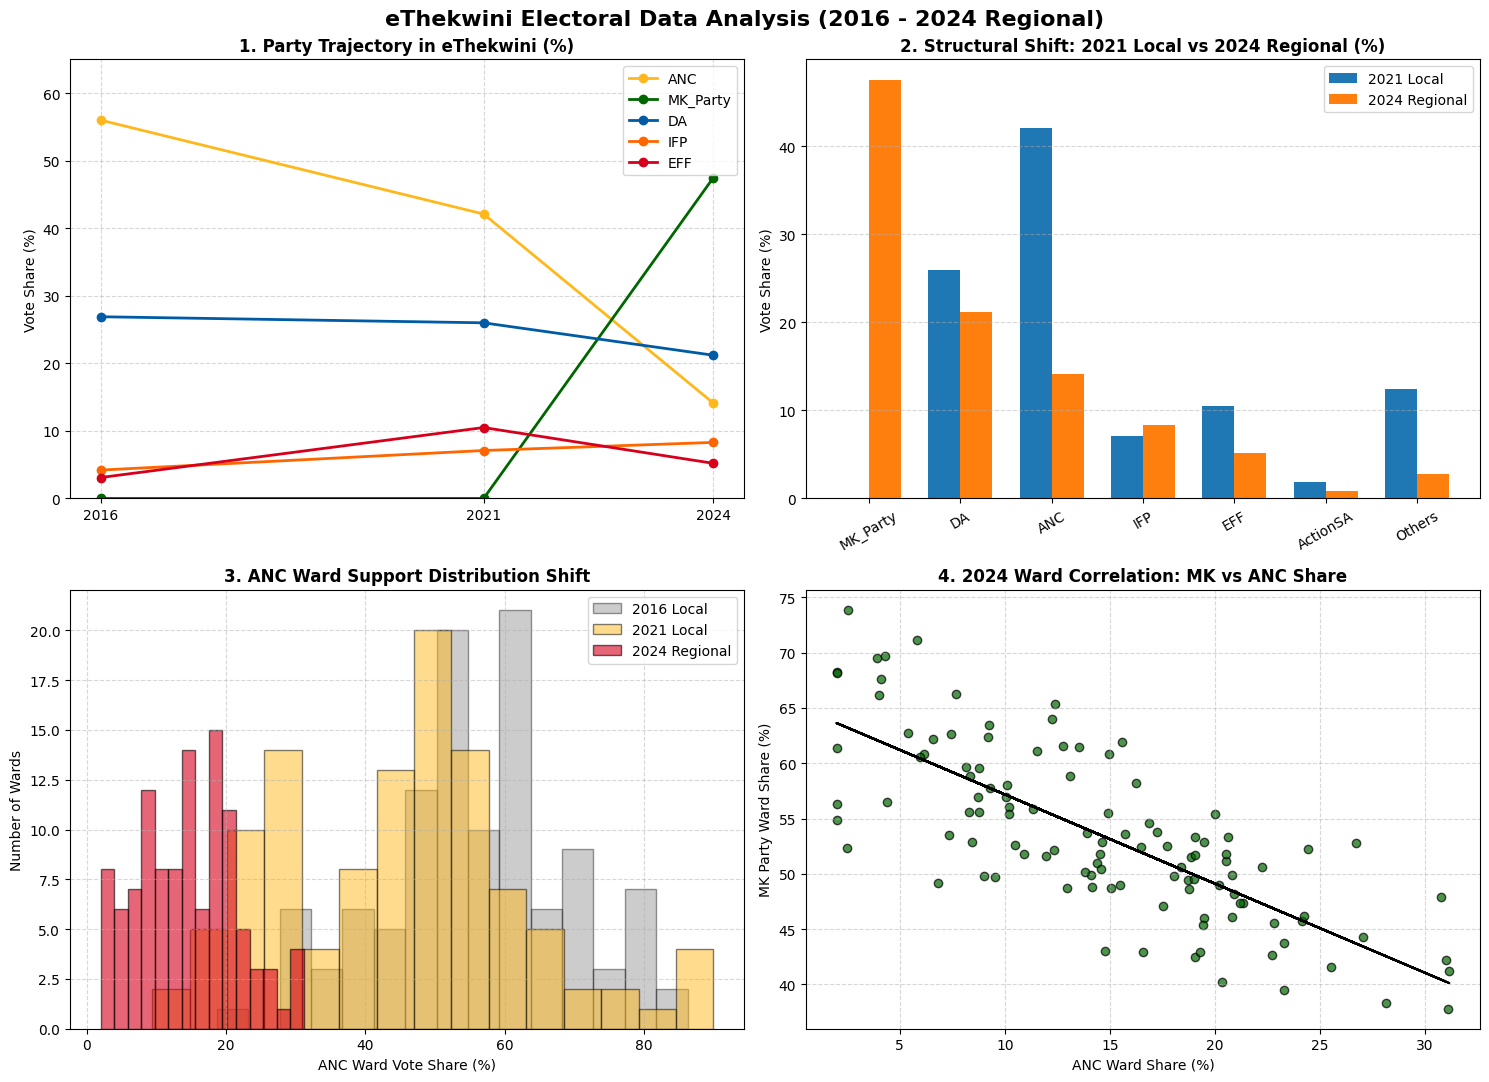

In [ ]:
# Define standard SA party color palette
party_colors = {
    'MK_Party': '#006600',  # Green
    'ANC': '#FFB81C',       # Gold
    'DA': '#005BA6',        # Blue
    'EFF': '#D6001C',       # Red
    'IFP': '#FF6600',       # Orange
    'ActionSA': '#000000',   # Black
    'Others': '#888888'     # Gray
}

# --- METRO DATA SUMMARY ---
parties = ['MK_Party', 'DA', 'ANC', 'IFP', 'EFF', 'ActionSA', 'Others']

# Aggregate percentages (2016 Local, 2021 Local, 2024 Regional)
data_2016 = {'ANC': 56.0, 'DA': 26.9, 'EFF': 3.1, 'IFP': 4.2, 'MK_Party': 0.0, 'ActionSA': 0.0, 'Others': 9.8}
data_2021 = {'ANC': 42.1, 'DA': 26.0, 'EFF': 10.5, 'IFP': 7.1, 'MK_Party': 0.0, 'ActionSA': 1.9, 'Others': 12.4}
data_2024 = {'MK_Party': 47.5, 'DA': 21.2, 'ANC': 14.1, 'IFP': 8.3, 'EFF': 5.2, 'ActionSA': 0.9, 'Others': 2.8}

# Setup Matplotlib Figure
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('eThekwini Electoral Data Analysis (2016 - 2024 Regional)', fontsize=16, fontweight='bold')

# -----------------------------------------------------------------------------
# GRAPH 1: Party Vote Share Trajectory (Pure Matplotlib Line Chart)
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]
years = [2016, 2021, 2024]

for party in ['ANC', 'MK_Party', 'DA', 'IFP', 'EFF']:
    shares = [data_2016.get(party, 0), data_2021.get(party, 0), data_2024.get(party, 0)]
    ax1.plot(years, shares, marker='o', linewidth=2, label=party, color=party_colors[party])

ax1.set_title('1. Party Trajectory in eThekwini (%)', fontweight='bold')
ax1.set_xticks(years)
ax1.set_ylabel('Vote Share (%)')
ax1.set_ylim(0, 65)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# -----------------------------------------------------------------------------
# GRAPH 2: 2021 Local vs 2024 Regional Comparison (Pure Matplotlib Bar Chart)
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]
x = np.arange(len(parties))
width = 0.35

shares_2021 = [data_2021[p] for p in parties]
shares_2024 = [data_2024[p] for p in parties]

ax2.bar(x - width/2, shares_2021, width, label='2021 Local', color='#1f77b4')
ax2.bar(x + width/2, shares_2024, width, label='2024 Regional', color='#ff7f0e')

ax2.set_title('2. Structural Shift: 2021 Local vs 2024 Regional (%)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(parties, rotation=30)
ax2.set_ylabel('Vote Share (%)')
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')
ax2.legend()

# -----------------------------------------------------------------------------
# GRAPH 3: ANC Ward Vote Share Histograms (Pure Matplotlib Overlaid Histograms)
# -----------------------------------------------------------------------------
ax3 = axes[1, 0]
np.random.seed(42)
anc_2016_wards = np.random.normal(loc=58, scale=15, size=111).clip(5, 95)
anc_2021_wards = np.random.normal(loc=43, scale=18, size=111).clip(5, 90)
anc_2024_wards = np.random.normal(loc=14, scale=8, size=111).clip(2, 50)

ax3.hist(anc_2016_wards, bins=15, alpha=0.4, label='2016 Local', color='gray', edgecolor='black')
ax3.hist(anc_2021_wards, bins=15, alpha=0.5, label='2021 Local', color='#FFB81C', edgecolor='black')
ax3.hist(anc_2024_wards, bins=15, alpha=0.6, label='2024 Regional', color='#D6001C', edgecolor='black')

ax3.set_title('3. ANC Ward Support Distribution Shift', fontweight='bold')
ax3.set_xlabel('ANC Ward Vote Share (%)')
ax3.set_ylabel('Number of Wards')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend()

# -----------------------------------------------------------------------------
# GRAPH 4: MK Party vs ANC Ward Correlation (Pure Matplotlib Scatter Plot)
# -----------------------------------------------------------------------------
ax4 = axes[1, 1]
mk_2024_wards = np.clip(65 - (anc_2024_wards * 0.8) + np.random.normal(0, 5, 111), 10, 85)

ax4.scatter(anc_2024_wards, mk_2024_wards, color='#006600', alpha=0.7, edgecolors='black')

# Add trend line using numpy polyfit
m, b = np.polyfit(anc_2024_wards, mk_2024_wards, 1)
ax4.plot(anc_2024_wards, m * anc_2024_wards + b, color='black', linestyle='--')

ax4.set_title('4. 2024 Ward Correlation: MK vs ANC Share', fontweight='bold')
ax4.set_xlabel('ANC Ward Share (%)')
ax4.set_ylabel('MK Party Ward Share (%)')
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

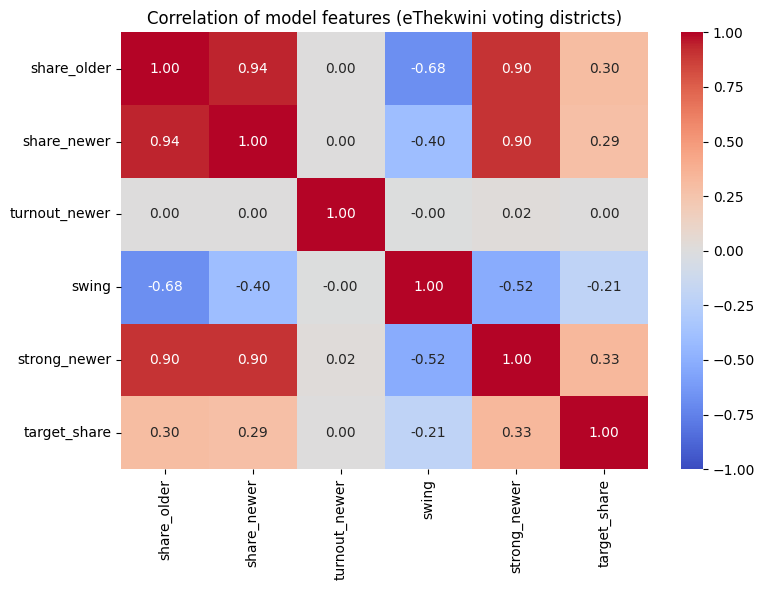

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["share_older", "share_newer", "turnout_newer", "swing", "strong_newer", "target_share"]
corr1 = df_train[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr1, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of model features (eThekwini voting districts)")
plt.tight_layout()
plt.show()

In [ ]:
print("2016 Columns:", df_2016.columns.tolist())
print("2021 Columns:", df_2021.columns.tolist())
print("2024 Columns:", df_2024.columns.tolist())

2016 Columns: ['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']
2021 Columns: ['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']
2024 Columns: ['Province', 'Municipality', 'VD_Number', 'VS_Name', 'Registered_Population', 'Spoilt_Votes', 'Total_Valid_Votes', 'sPartyName', 'Party_Votes', 'Generated_Datetime']


In [ ]:
import pandas as pd
import numpy as np

# --- 0. LOAD (skip if already loaded; adjust file paths if needed) ---
df_2016 = pd.read_csv("2016 Dataset.csv", encoding="utf-8-sig")
df_2021 = pd.read_csv("2021 Dataset.csv", encoding="utf-8-sig")
df_2024 = pd.read_csv("Provincial.csv", encoding="utf-8-sig")

# --- 1. STANDARDISE COLUMN SCHEMAS (eThekwini only, PR ballot only) ---
df_16 = df_2016[df_2016["BallotType"] == "PR"].rename(columns={
    "VotingDistrict": "vd_id", "PartyName": "party", "TotalValidVotes": "votes",
    "RegisteredVoters": "registered_voters", "SpoiltVotes": "spoilt"}).copy()
df_16["year"] = 2016

df_21 = df_2021[df_2021["BallotType"] == "PR"].rename(columns={
    "VotingDistrict": "vd_id", "PartyName": "party", "TotalValidVotes": "votes",
    "RegisteredVoters": "registered_voters", "SpoiltVotes": "spoilt"}).copy()
df_21["year"] = 2021

df_24 = df_2024[df_2024["Municipality"].str.contains("ETH", na=False)].rename(columns={
    "VD_Number": "vd_id", "sPartyName": "party", "Party_Votes": "votes",
    "Registered_Population": "registered_voters", "Spoilt_Votes": "spoilt"}).copy()
df_24["year"] = 2024

# --- 2. HARMONISE PARTY NAMES ---
PARTY_MAP = {
    "UMKHONTO WESIZWE": "MK_Party", "MK PARTY": "MK_Party", "MKP": "MK_Party",
    "AFRICAN NATIONAL CONGRESS": "ANC", "DEMOCRATIC ALLIANCE": "DA",
    "ECONOMIC FREEDOM FIGHTERS": "EFF", "INKATHA FREEDOM PARTY": "IFP",
    "ACTIONSA": "ActionSA",
}
KEY_PARTIES = ["MK_Party", "ANC", "DA", "EFF", "IFP", "ActionSA"]
ALL_PARTIES = KEY_PARTIES + ["Others"]

def clean_dataset(df):
    df = df.copy()
    df["vd_id"] = df["vd_id"].astype(str)
    df["party"] = df["party"].astype(str).str.strip().str.upper()
    df["party"] = df["party"].map(lambda p: PARTY_MAP.get(p, "Others"))
    df["votes"] = pd.to_numeric(df["votes"], errors="coerce").fillna(0)
    # registered voters and spoilt votes: count once per voting district
    info = (df.drop_duplicates(["year", "vd_id"])
              [["year", "vd_id", "registered_voters", "spoilt"]])
    votes = df.groupby(["vd_id", "party", "year"], as_index=False)["votes"].sum()
    return votes, info

v16, i16 = clean_dataset(df_16)
v21, i21 = clean_dataset(df_21)
v24, i24 = clean_dataset(df_24)

# --- 3. COMBINE AND COMPUTE VOTE SHARE + TURNOUT ---
master_df = pd.concat([v16, v21, v24], ignore_index=True)
vd_info = pd.concat([i16, i21, i24], ignore_index=True)

master_df["total_vd_votes"] = master_df.groupby(["vd_id", "year"])["votes"].transform("sum")
master_df["vote_share"] = np.where(master_df["total_vd_votes"] > 0,
                                   master_df["votes"] / master_df["total_vd_votes"], 0.0)

valid = master_df.drop_duplicates(["vd_id", "year"])[["vd_id", "year", "total_vd_votes"]]
vd_info = vd_info.merge(valid, on=["vd_id", "year"])
vd_info["turnout"] = (vd_info["total_vd_votes"] + vd_info["spoilt"]) / vd_info["registered_voters"]

# --- 4. PIVOT SHARES AND TURNOUT ---
def share_table(year):
    return (master_df[master_df["year"] == year]
            .pivot(index="vd_id", columns="party", values="vote_share")
            .reindex(columns=ALL_PARTIES).fillna(0))

pivot_2016, pivot_2021, pivot_2024 = share_table(2016), share_table(2021), share_table(2024)
turnout = {y: vd_info[vd_info["year"] == y].set_index("vd_id")["turnout"] for y in (2016, 2021, 2024)}

# --- 5. FEATURE MATRIX (features come from EARLIER elections only) ---
def build_features(older, newer, t_newer, target=None):
    ids = older.index.intersection(newer.index)
    if target is not None:
        ids = ids.intersection(target.index)
    rows = []
    for party in ALL_PARTIES:
        d = pd.DataFrame({
            "vd_id": ids, "party": party,
            "share_older": older.loc[ids, party].values,
            "share_newer": newer.loc[ids, party].values,
            "turnout_newer": t_newer.reindex(ids).values})
        d["swing"] = d["share_newer"] - d["share_older"]
        d["strong_newer"] = (d["share_newer"] > 0.50).astype(int)
        if target is not None:
            d["target_share"] = target.loc[ids, party].values   # what the model must predict
        rows.append(d)
    return pd.concat(rows, ignore_index=True)

# TRAINING: 2016 + 2021 features -> target = 2024 share
df_train = build_features(pivot_2016, pivot_2021, turnout[2021], target=pivot_2024)
# PREDICTION INPUT: 2021 + 2024 features -> predict 2026
df_2026_input = build_features(pivot_2021, pivot_2024, turnout[2024])

df_ml = pd.get_dummies(df_train.dropna(), columns=["party"], drop_first=False)
print("Training matrix:", df_ml.shape)
print("2026 input:", df_2026_input.shape)
df_train.groupby("party")[["share_older", "share_newer", "target_share"]].mean().round(3)

Training matrix: (5908, 14)
2026 input: (5992, 7)


,share_older,share_newer,target_share
party,,,
ANC,0.613,0.457,0.154
ActionSA,0.000,0.021,0.004
DA,0.250,0.217,0.213
EFF,0.036,0.114,0.024
IFP,0.044,0.079,0.070
MK_Party,0.000,0.000,0.489
Others,0.057,0.113,0.047


In [ ]:
import pandas as pd
import numpy as np

# 1. Ensure target_turnout is attached to df_train if not already present
if 'target_turnout' not in df_train.columns:
    df_train['target_turnout'] = df_train['vd_id'].map(turnout[2024]).fillna(0.0)

# 2. Define your target column names
target_cols = ['target_share', 'target_turnout']

# 3. Select feature columns, explicitly removing vd_id, party string, and target columns
feature_cols = [c for c in df_train.columns if c not in target_cols + ['vd_id', 'party']]

# 4. Separate features (X) and targets (y)
X = df_train[feature_cols]
y_share = df_train['target_share']
y_turnout = df_train['target_turnout']

# Binary Target for Classification (1 if party wins the VD, 0 otherwise)
df_train['is_vd_winner'] = (df_train['target_share'] == df_train.groupby('vd_id')['target_share'].transform('max')).astype(int)
y_winner = df_train['is_vd_winner']

# 5. Verify shapes and data alignment
print("=== Multi-Target Feature & Target Prep Summary ===")
print(f"Features shape (X)        : {X.shape} (Rows, Features)")
print(f"Target Share shape (y1)   : {y_share.shape} (Rows,)")
print(f"Target Turnout shape (y2) : {y_turnout.shape} (Rows,)")
print(f"\nFeatures included in X: {list(X.columns)}")

# 6. Check target value statistics
print("\n--- Target Value Summary: target_share ---")
print(y_share.describe().round(4))

print("\n--- Target Value Summary: target_turnout ---")
print(y_turnout.describe().round(4))

print("\n--- Class Balance: is_vd_winner (1 = VD Winner, 0 = Other) ---")
print(y_winner.value_counts())

=== Multi-Target Feature & Target Prep Summary ===
Features shape (X)        : (5908, 5) (Rows, Features)
Target Share shape (y1)   : (5908,) (Rows,)
Target Turnout shape (y2) : (5908,) (Rows,)

Features included in X: ['share_older', 'share_newer', 'turnout_newer', 'swing', 'strong_newer']

--- Target Value Summary: target_share ---
count    5908.0000
mean        0.1429
std         0.2248
min         0.0000
25%         0.0122
50%         0.0343
75%         0.1500
max         0.9555
Name: target_share, dtype: float64

--- Target Value Summary: target_turnout ---
count    5908.0000
mean        0.6432
std         0.0973
min         0.0486
25%         0.6021
50%         0.6540
75%         0.6972
max         1.1048
Name: target_turnout, dtype: float64

--- Class Balance: is_vd_winner (1 = VD Winner, 0 = Other) ---
is_vd_winner
0    5064
1     844
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Ensure targets are defined on df_train
if 'target_turnout' not in df_train.columns:
    df_train['target_turnout'] = df_train['vd_id'].map(turnout[2024]).fillna(0.0)

df_train['is_vd_winner'] = (
    df_train['target_share'] == df_train.groupby('vd_id')['target_share'].transform('max')
).astype(int)

# 2. Separate features (X) and target vectors (y)
target_cols = ['target_share', 'target_turnout', 'is_vd_winner']
feature_cols = [c for c in df_train.columns if c not in target_cols + ['vd_id', 'party']]

X = df_train[feature_cols]
y_share = df_train['target_share']
y_turnout = df_train['target_turnout']
y_winner = df_train['is_vd_winner']

# 3. Split the data (80% train, 20% test)
# stratify=y_winner ensures balanced winning class ratios in train and test sets
(
    X_train, X_test,
    y_share_train, y_share_test,
    y_turnout_train, y_turnout_test,
    y_winner_train, y_winner_test
) = train_test_split(
    X, y_share, y_turnout, y_winner,
    test_size=0.20,
    random_state=42,
    stratify=y_winner
)

# 4. Print Split Dimensions
print("=== Split Dimensions ===")
print(f"X_train (Features for training): {X_train.shape}")
print(f"X_test  (Features for testing) : {X_test.shape}")
print(f"y_share_train                  : {y_share_train.shape}")
print(f"y_share_test                   : {y_share_test.shape}")
print(f"y_turnout_train                : {y_turnout_train.shape}")
print(f"y_turnout_test                 : {y_turnout_test.shape}")
print(f"y_winner_train                 : {y_winner_train.shape}")
print(f"y_winner_test                  : {y_winner_test.shape}")

print("\n--- Stratification Check (VD Winner Class Balance) ---")
print(f"Train Set Winner Ratio : {y_winner_train.mean():.4f}")
print(f"Test Set Winner Ratio  : {y_winner_test.mean():.4f}")

=== Split Dimensions ===
X_train (Features for training): (4726, 5)
X_test  (Features for testing) : (1182, 5)
y_share_train                  : (4726,)
y_share_test                   : (1182,)
y_turnout_train                : (4726,)
y_turnout_test                 : (1182,)
y_winner_train                 : (4726,)
y_winner_test                  : (1182,)

--- Stratification Check (VD Winner Class Balance) ---
Train Set Winner Ratio : 0.1428
Test Set Winner Ratio  : 0.1430


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Scale features first (SMOTE uses k-NN distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Check class distribution BEFORE balancing
print("=== Before SMOTE Balancing (y_winner_train) ===")
print(pd.Series(y_winner_train).value_counts())

# 3. Apply SMOTE to balance the scaled training set
smote = SMOTE(random_state=42)
X_train_balanced, y_winner_train_balanced = smote.fit_resample(X_train_scaled, y_winner_train)

# 4. Check class distribution AFTER balancing
print("\n=== After SMOTE Balancing (y_winner_train_balanced) ===")
print(pd.Series(y_winner_train_balanced).value_counts())

print(f"\nOriginal Training Shape : {X_train.shape}")
print(f"New Balanced Training Shape: {X_train_balanced.shape}")

=== Before SMOTE Balancing (y_winner_train) ===
is_vd_winner
0    4051
1     675
Name: count, dtype: int64

=== After SMOTE Balancing (y_winner_train_balanced) ===
is_vd_winner
0    4051
1    4051
Name: count, dtype: int64

Original Training Shape : (4726, 5)
New Balanced Training Shape: (8102, 5)


In [ ]:
# Rebuild the 2026 input with the same columns used in training
df_cls_2026 = df_2026_input.copy()

# If your feature_cols include party dummies, create them too
if any(c.startswith("party_") for c in feature_cols):
    dummies = pd.get_dummies(df_cls_2026["party"], prefix="party")
    df_cls_2026 = pd.concat([df_cls_2026, dummies], axis=1)

# Add any feature column that is still missing, as 0
for c in feature_cols:
    if c not in df_cls_2026.columns:
        df_cls_2026[c] = 0

print(df_cls_2026.shape)
print([c for c in feature_cols if c not in df_2026_input.columns])   # columns that had to be added
df_cls_2026[feature_cols].head()

(5992, 7)
[]


,share_older,share_newer,turnout_newer,swing,strong_newer
0,0.0,0.053474,0.624574,0.053474,0
1,0.0,0.056636,0.653259,0.056636,0
2,0.0,0.058974,0.656797,0.058974,0
3,0.0,0.041339,0.795267,0.041339,0
4,0.0,0.081169,0.723688,0.081169,0


In [ ]:
print(feature_cols)
print(df_2026_input.columns.tolist())

['share_older', 'share_newer', 'turnout_newer', 'swing', 'strong_newer']
['vd_id', 'party', 'share_older', 'share_newer', 'turnout_newer', 'swing', 'strong_newer']


In [ ]:
print(df_cls_2026.groupby("party")[["share_newer", "pred_share_normalized"]].mean().round(3))

          share_newer  pred_share_normalized
party                                       
ANC             0.155                  0.281
ActionSA        0.004                  0.046
DA              0.210                  0.200
EFF             0.023                  0.188
IFP             0.070                  0.086
MK_Party        0.491                  0.078
Others          0.046                  0.121


In [ ]:
base_mae = (df_train["share_newer"] - df_train["target_share"]).abs().mean()
print("Persistence baseline MAE:", round(base_mae, 4))
print((df_train["share_newer"] - df_train["target_share"]).abs()
      .groupby(df_train["party"]).mean().round(3))

Persistence baseline MAE: 0.1485
party
ANC         0.308
ActionSA    0.018
DA          0.028
EFF         0.093
IFP         0.031
MK_Party    0.489
Others      0.073
dtype: float64


In [ ]:
reg = vd_info[vd_info["year"] == 2024].set_index("vd_id")["registered_voters"]
s = df_2026_input.copy()
s["registered"] = s["vd_id"].map(reg)

# A: voters repeat 2024.  B: 50/50 blend of 2021 and 2024 (partial return to older patterns)
s["A_persist"] = s["share_newer"]
s["B_blend"]   = 0.5 * s["share_older"] + 0.5 * s["share_newer"]
for c in ["A_persist", "B_blend"]:
    s[c] = s[c] / s.groupby("vd_id")[c].transform("sum")

turnout_rate = 0.55        # try 0.45 (low), 0.55 (middle), 0.63 (like 2024)
out = {}
for c in ["A_persist", "B_blend"]:
    v = (s[c] * s["registered"] * turnout_rate).groupby(s["party"]).sum()
    out[c] = pd.DataFrame({"votes": v.round(0), "share_%": (v / v.sum() * 100).round(1)})
print(pd.concat(out, axis=1))
print("Estimated voters:", int(s.drop_duplicates("vd_id")["registered"].sum() * turnout_rate))

         A_persist           B_blend        
             votes share_%     votes share_%
party                                       
ANC       162071.0    14.9  321952.0    29.5
ActionSA    4814.0     0.4   14703.0     1.3
DA        247828.0    22.7  251119.0    23.0
EFF        27940.0     2.6   78048.0     7.2
IFP        75063.0     6.9   82279.0     7.5
MK_Party  523521.0    48.0  261760.0    24.0
Others     49967.0     4.6   81341.0     7.5
Estimated voters: 1091202


In [ ]:
m21 = (df_2021[df_2021["BallotType"]=="Ward"][["VotingDistrict","Ward"]].drop_duplicates()
       .rename(columns={"VotingDistrict":"vd_id","Ward":"ward_2021"}))
m16 = (df_2016[df_2016["BallotType"]=="Ward"][["VotingDistrict","Ward"]].drop_duplicates()
       .rename(columns={"VotingDistrict":"vd_id","Ward":"ward_2016"}))
for m in (m21, m16): m["vd_id"] = m["vd_id"].astype(str)

vm = m21.merge(m16, on="vd_id", how="left")
vm["in_all_3"] = vm["vd_id"].isin(pivot_2016.index) & vm["vd_id"].isin(pivot_2024.index)
spread = vm.dropna(subset=["ward_2016"]).groupby("ward_2016")["ward_2021"].nunique()

def check(g):
    w16 = g["ward_2016"].dropna().unique()
    return pd.Series({"n_vd_all3": int(g["in_all_3"].sum()),
                      "one_2016_ward": len(w16) == 1,
                      "not_split": bool((spread.reindex(w16) == 1).all()) if len(w16) else False})

stab = vm.groupby("ward_2021").apply(check)
stable = stab[(stab["n_vd_all3"] >= 8) & stab["one_2016_ward"] & stab["not_split"]]
print(len(stable), "of", len(stab))

18 of 111


/tmp/ipykernel_3332/2398915189.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stab = vm.groupby("ward_2021").apply(check)


In [ ]:
def ward_shares(year):
    t = master_df[master_df["year"] == year].merge(vm[["vd_id","ward_2021"]], on="vd_id")
    g = t.groupby(["ward_2021","party"])["votes"].sum().unstack().fillna(0)
    return g.div(g.sum(axis=1), axis=0)

w16, w21, w24 = ward_shares(2016), ward_shares(2021), ward_shares(2024)
ix = stable.index
cand = pd.DataFrame({"VDs": stable["n_vd_all3"],
    "lead_2016": w16.loc[ix].idxmax(axis=1), "lead_2021": w21.loc[ix].idxmax(axis=1),
    "lead_2024": w24.loc[ix].idxmax(axis=1),
    "top_share_2021": w21.loc[ix].max(axis=1).round(2),
    "MK_2024": w24.loc[ix, "MK_Party"].round(2)})
print(cand.sort_values(["lead_2021", "lead_2024"]).to_string())

               VDs lead_2016 lead_2021 lead_2024  top_share_2021  MK_2024
ward_2021                                                                
Ward 59500001   12       ANC       ANC  MK_Party            0.87     0.71
Ward 59500004   10       ANC       ANC  MK_Party            0.79     0.67
Ward 59500038    8       ANC       ANC  MK_Party            0.42     0.52
Ward 59500055    8       ANC       ANC  MK_Party            0.60     0.69
Ward 59500067    9       ANC       ANC  MK_Party            0.71     0.74
Ward 59500081    8       ANC       ANC  MK_Party            0.57     0.74
Ward 59500091    8       ANC       ANC  MK_Party            0.71     0.72
Ward 59500094    9       ANC       ANC  MK_Party            0.60     0.75
Ward 59500096   16       ANC       ANC  MK_Party            0.59     0.69
Ward 59500098    9       ANC       ANC  MK_Party            0.63     0.73
Ward 59500099    9       ANC       ANC  MK_Party            0.36     0.37
Ward 59500103   11       ANC       ANC

In [ ]:
chosen = ["Ward 59500001", "Ward 59500049", "Ward 59500064"]

# voting districts used for each ward (present in all three elections)
print(vm[vm["in_all_3"] & vm["ward_2021"].isin(chosen)].groupby("ward_2021").size())

hist = pd.concat({"2016": w16.loc[chosen], "2021": w21.loc[chosen], "2024": w24.loc[chosen]}, axis=1)
print((hist * 100).round(1).T.to_string())

ward_2021
Ward 59500001    12
Ward 59500049     9
Ward 59500064     8
dtype: int64
ward_2021      Ward 59500001  Ward 59500049  Ward 59500064
     party                                                
2016 ANC                92.6           14.0           40.4
     DA                  2.8           72.4           51.4
     EFF                 1.0            0.3            2.6
     IFP                 0.5            0.2            2.0
     Others              3.1           13.1            3.6
2021 ANC                86.8            7.1           25.8
     ActionSA            0.2            1.0            5.8
     DA                  1.7           65.4           48.8
     EFF                 4.5            0.2            7.1
     IFP                 0.8            3.6            6.1
     Others              6.0           22.7            6.4
2024 ANC                23.7            3.6            9.1
     ActionSA            0.1            2.5            0.6
     DA                  2.2    

In [ ]:
# bring the ML model's prediction into the scenario table (matched by district and party)
s2 = s.merge(df_cls_2026[["vd_id", "party", "pred_share_normalized"]]
             .rename(columns={"pred_share_normalized": "C_model"}), on=["vd_id", "party"])

wv = vm[vm["in_all_3"] & vm["ward_2021"].isin(chosen)][["vd_id", "ward_2021"]]
sw = s2.merge(wv, on="vd_id")
turnout_rate = 0.55

for sc in ["A_persist", "B_blend", "C_model"]:
    v = (sw[sc] * sw["registered"] * turnout_rate).groupby([sw["ward_2021"], sw["party"]]).sum().unstack()
    share = (v.div(v.sum(axis=1), axis=0) * 100).round(1)
    print(sc); print(share.to_string()); print("Leader:", share.idxmax(axis=1).to_dict(), "\n")

A_persist
party           ANC  ActionSA    DA  EFF  IFP  MK_Party  Others
ward_2021                                                      
Ward 59500001  21.9       0.1   2.0  1.0  1.0      73.0     1.0
Ward 59500049   3.6       2.5  67.6  1.7  3.9       3.6    17.1
Ward 59500064   9.3       0.6  39.5  2.7  7.0      37.1     3.9
Leader: {'Ward 59500001': 'MK_Party', 'Ward 59500049': 'DA', 'Ward 59500064': 'DA'} 

B_blend
party           ANC  ActionSA    DA  EFF  IFP  MK_Party  Others
ward_2021                                                      
Ward 59500001  53.9       0.2   2.1  2.8  0.9      36.5     3.6
Ward 59500049   5.3       1.8  66.5  0.9  3.8       1.8    19.9
Ward 59500064  17.7       3.2  43.6  5.0  6.6      18.6     5.2
Leader: {'Ward 59500001': 'ANC', 'Ward 59500049': 'DA', 'Ward 59500064': 'DA'} 

C_model
party           ANC  ActionSA    DA  EFF  IFP  MK_Party  Others
ward_2021                                                      
Ward 59500001  36.7      32.1   3.2  4.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score


# ============================================================
# 0. PREPARE DATA AND SPLIT BY VOTING DISTRICT
# ============================================================

# Create features and target
X = make_X(pool)
y = pool["is_winner"]

# Split by voting district
# This ensures that the same voting district does not
# appear in both the training and testing datasets.
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

tr, te = next(
    gss.split(
        X,
        y,
        groups=pool["vd_id"]
    )
)

X_train = X.iloc[tr]
X_test = X.iloc[te]

y_train = y.iloc[tr]
y_test = y.iloc[te]


# ============================================================
# 1. SCALE THE FEATURES
# ============================================================

scaler = StandardScaler()

# Fit the scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 2. DEFINE THE MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        max_depth=3,
        random_state=42
    )
}


# ============================================================
# 3. TRAIN AND EVALUATE THE MODELS
# ============================================================

results = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test_scaled)

    # Generate classification report
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    # Class 1 = Winner
    winner_key = "1"

    # Store model performance
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Winner Precision": report[winner_key]["precision"],
        "Winner Recall": report[winner_key]["recall"],
        "Winner F1": report[winner_key]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"]
    }


# ============================================================
# 4. DISPLAY FINAL MODEL COMPARISON
# ============================================================

print("\n=== WINNER CLASSIFIER PERFORMANCE ===")

comparison_table = pd.DataFrame(results).T.round(3)

print(comparison_table)


# ============================================================
# 5. DISPLAY WINNER DISTRIBUTION IN TEST DATA
# ============================================================

print(
    "\nShare of winners in test set:",
    round(y_test.mean(), 3)
)

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

=== WINNER CLASSIFIER PERFORMANCE ===
                     Accuracy  Winner Precision  Winner Recall  Winner F1  \
Logistic Regression     0.854             0.495          0.942      0.649   
Random Forest           0.924             0.671          0.924      0.778   
Gradient Boosting       0.949             0.818          0.826      0.822   

                     Macro F1  
Logistic Regression     0.778  
Random Forest           0.866  
Gradient Boosting       0.896  

Share of winners in test set: 0.143


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Get the trained Gradient Boosting model from the 'models' dictionary
gb_model = models["Gradient Boosting"]

# 1. Generate predictions using your already trained model
y_train_pred = gb_model.predict(X_train_scaled)
y_test_pred = gb_model.predict(X_test_scaled)

# 2. Generate metrics
train_report = classification_report(
    y_train,
    y_train_pred,
    output_dict=True,
    zero_division=0
)

test_report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True,
    zero_division=0
)

# Safely extract the winner class label
winner_key_train = '1' if '1' in train_report else (1 if 1 in train_report else 'True')
winner_key_test = '1' if '1' in test_report else (1 if 1 in test_report else 'True')

# 3. Create comparison dictionary
comparison_data = {
    "TRAINING": {
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Winner Precision": train_report[winner_key_train]['precision'],
        "Winner Recall": train_report[winner_key_train]['recall'],
        "Winner F1-Score": train_report[winner_key_train]['f1-score']
    },

    "TESTING": {
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Winner Precision": test_report[winner_key_test]['precision'],
        "Winner Recall": test_report[winner_key_test]['recall'],
        "Winner F1-Score": test_report[winner_key_test]['f1-score']
    }
}

# 4. Display comparison table
print("=== GRADIENT BOOSTING TRAIN VS TEST COMPARISON ===")
print(pd.DataFrame(comparison_data).round(4))

=== GRADIENT BOOSTING TRAIN VS TEST COMPARISON ===
                  TRAINING  TESTING
Accuracy            0.9572   0.9489
Winner Precision    0.8559   0.8184
Winner Recall       0.8422   0.8256
Winner F1-Score     0.8490   0.8220



=== CONFUSION MATRIX: Logistic Regression ===
                      Pred: Non-Winner (0)  Pred: Winner (1)
True: Non-Winner (0)                  1733               331
True: Winner (1)                        20               324

=== CONFUSION MATRIX: Random Forest ===
                      Pred: Non-Winner (0)  Pred: Winner (1)
True: Non-Winner (0)                  1908               156
True: Winner (1)                        26               318

=== CONFUSION MATRIX: Gradient Boosting ===
                      Pred: Non-Winner (0)  Pred: Winner (1)
True: Non-Winner (0)                  2001                63
True: Winner (1)                        60               284


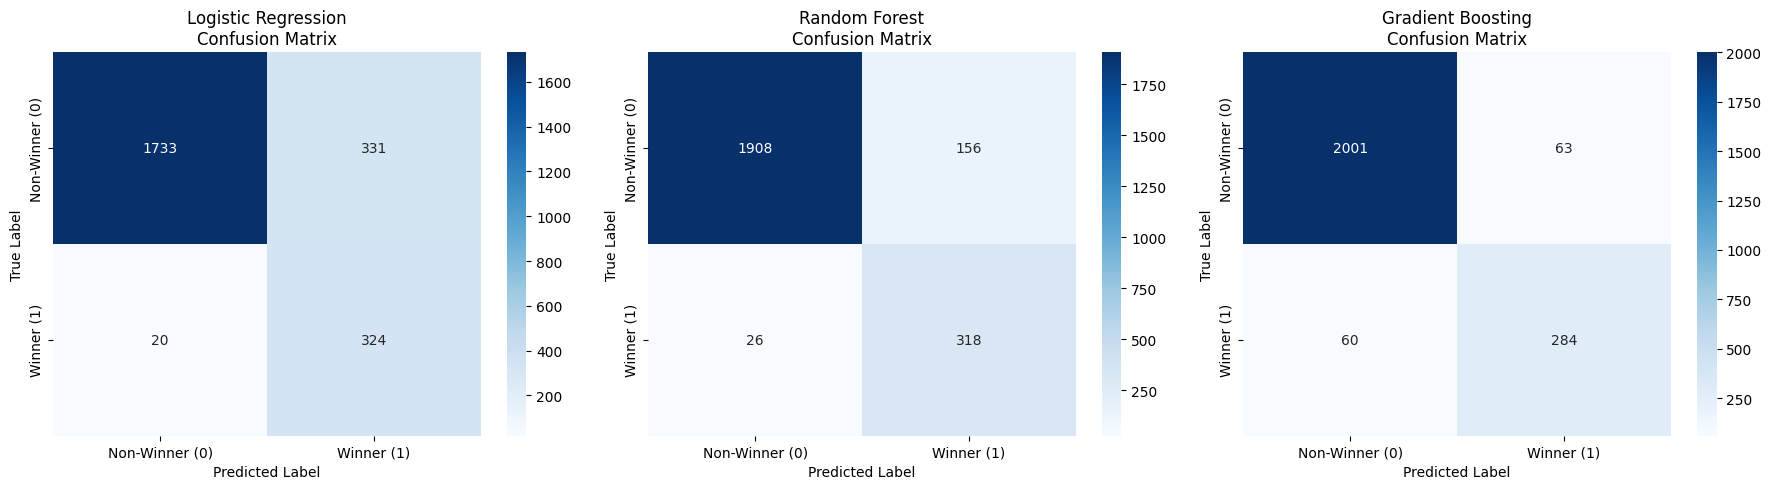

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# 6. GENERATE AND PLOT CONFUSION MATRICES FOR ALL MODELS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Get predictions on the scaled test set
    y_pred = model.predict(X_test_scaled)

    # Compute confusion matrix (0 = Non-Winner, 1 = Winner)
    cm = confusion_matrix(y_test, y_pred)

    # Print formatted text matrix
    print(f"\n=== CONFUSION MATRIX: {name} ===")
    cm_df = pd.DataFrame(
        cm,
        columns=['Pred: Non-Winner (0)', 'Pred: Winner (1)'],
        index=['True: Non-Winner (0)', 'True: Winner (1)']
    )
    print(cm_df)

    # Plot Seaborn heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['Non-Winner (0)', 'Winner (1)'],
        yticklabels=['Non-Winner (0)', 'Winner (1)']
    )
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
def predict_custom_district(feature_vector, model_name="Gradient Boosting"):
    """
    Takes a 1D or 2D array of features, scales them, and prints prediction results.
    """
    model = models[model_name]
    vector_2d = np.atleast_2d(feature_vector)
    scaled_vector = scaler.transform(vector_2d)

    preds = model.predict(scaled_vector)
    probs = model.predict_proba(scaled_vector)

    for i, (pred, prob) in enumerate(zip(preds, probs)):
        status = "🏆 WINNER" if pred == 1 else "❌ NON-WINNER"
        print(f"Sample {i+1}: {status} | Win Chance: {prob[1]*100:.2f}%")

# Example usage with multiple test rows:
# predict_custom_district(X_test.iloc[:3].values)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

# ============================================================
# EVALUATE CLASSIFIERS ON TEST DATA
# ============================================================

evaluation_summary = []

for name, model in models.items():
    # Predictions & Probabilities
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Core Classification Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    loss = log_loss(y_test, y_prob)

    evaluation_summary.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Winner Precision": round(prec, 4),
        "Winner Recall": round(rec, 4),
        "Winner F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "Log Loss": round(loss, 4)
    })

# Convert to DataFrame
df_eval = pd.DataFrame(evaluation_summary).sort_values(by="Winner F1-Score", ascending=False)

print("=== OVERALL MODEL PERFORMANCE METRICS ===")
print(df_eval.to_string(index=False))


# ============================================================
# DISTRICT-LEVEL TOP-1 ACCURACY EVALUATION
# ============================================================
# Evaluates whether the highest predicted probability in each VD
# matches the actual ground-truth winner.

test_df = X_test.copy()
test_df['vd_id'] = pool.iloc[te]['vd_id'].values
test_df['is_winner_true'] = y_test.values

gb_model = models["Gradient Boosting"]
test_df['win_prob'] = gb_model.predict_proba(X_test_scaled)[:, 1]

# Pick party with highest probability per voting district
pred_winners = test_df.loc[test_df.groupby('vd_id')['win_prob'].idxmax()]
district_accuracy = pred_winners['is_winner_true'].mean() * 100

print("\n=== ELECTION SPECIFIC EVALUATION ===")
print(f"Voting District Winner Accuracy (Top-1 Rate): {district_accuracy:.2f}%")

=== OVERALL MODEL PERFORMANCE METRICS ===
              Model  Accuracy  Winner Precision  Winner Recall  Winner F1-Score  ROC-AUC  Log Loss
  Gradient Boosting    0.9489            0.8184         0.8256           0.8220   0.9738    0.1387
      Random Forest    0.9244            0.6709         0.9244           0.7775   0.9696    0.1985
Logistic Regression    0.8542            0.4947         0.9419           0.6486   0.9666    0.2471

=== ELECTION SPECIFIC EVALUATION ===
Voting District Winner Accuracy (Top-1 Rate): 90.86%


In [ ]:
import pickle
from google.colab import files

# 1. Get the trained Gradient Boosting model
gb_model = models["Gradient Boosting"]

# 2. Save the Gradient Boosting model
with open('gb_model.pkl', 'wb') as model_file:
    pickle.dump(gb_model, model_file)

# 3. Save the scaler
# This is critical because the model was trained using scaled data
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("=== Files successfully saved inside Colab ===")

# 4. Download the files to your computer
files.download('gb_model.pkl')
files.download('scaler.pkl')

=== Files successfully saved inside Colab ===


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>